### **Analysis and Visualization Notebook:**
This notebook analyses reported urban issues from the ZüriWieNeu platform in the city of Zurich. In the previous notebooks, the raw report data were cleaned, converted into spatial point data, and joined with Zurich neighbourhood polygons. As a result, each report is now connected to a specific neighbourhood.

The goal of this notebook is to use the prepared spatial dataset to explore patterns in reported urban issues across Zurich. The analysis focuses on both spatial and temporal patterns, such as which neighbourhoods receive the most reports, which problem categories are most common, and whether certain types of issues are concentrated in specific areas.

The dataset used in this notebook is the processed GeoPackage created after the spatial join : reports_with_quartiere. It contains the cleaned report attributes, point geometries, and neighbourhood information such as neighbourhood name, neighbourhood number, district name, and district number.

By the end of this notebook, five research questions will be answered using code, summary tables, plots, and maps. These results help to better understand how reported urban problems are distributed across Zurich and how they vary by category, neighbourhood, and time.

Expected output *(which is saved in ../output/maps and ../output/tables)*:
- a visualisation (map) of the report datapoints and the neighborhoods (polygons)
- a table and visualization (bar chart) of which neighborhood and Kreis receives the highest amount of reports
- a table, little detailed insight, and visualization(bar chart) of which category of report is most common
- a visualization (line chart) of the progress of reports per month and per year
- a frequencytable of absolut count of each cateogry in the neighborhoods
- a visualisation (map) of the dominat category in each neighborhood, but without the most dominant category "Abfall/Sammelstelle"
- a table /statistics on the progressing time of each category and neighborhood(top 5)
- a visualisation (barchart) of the progressing time of each category and neighborhood

---
**Loading and Checking the data:**
Firstly the necessary libarie for this notebook were imported. Panda is needed to change datetimes into date data types. Geopandas is needed to load a GeoDataFrame, and matplotlib.pyplot is needed for poltting visualizations. Cmcrameri is useful for coloured maping. Contextilty is useful for basemaps.

Some options were set, so that the export in the end is not influenced by to big tables.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
import contextily as ctx

pd.set_option("display.max_columns", 6)
pd.set_option("display.width", 100)
pd.set_option("display.max_colwidth", 60)

The processed Geopackage is loaded as GeoDataFrame. This dataset already contains both the report information and the neighbourhood information from the spatial join.

In [2]:
#layer reports with quartiere, because it was safed in that layer
reports_with_quartiere = gpd.read_file(
    "../data/processeddata/reports_with_quartiere.gpkg",
    layer="reports_with_quartiere"
)

Additionally, the zh_quartiere_clean is also loaded into this Notebook as a GeoDataFrame so visualizations with the geometry of the boundaries is possible.

In [3]:
zh_quartiere_clean = gpd.read_file("../data/processeddata/zh_quartiere_clean.gpkg", 
                                   layer="zh_quartiere_clean").to_crs(epsg=2056)


Secondly, the loaded joined GeoeDataFrame is inspected, to make sure, every important variable is available and the data frame is complete. For that, i use some basic definitions, like .head(), .info(), .crs.

In [4]:
reports_with_quartiere.head(2)

,service_request_id,requested_datetime,updated_datetime,...,kreis_name,kreis_number,geometry
0,1,2013-03-14 15:16:15,2013-04-12 07:59:30,...,Kreis 9,9,POINT (2678968 1247548)
1,2,2013-03-14 15:17:57,2013-04-12 08:00:22,...,Kreis 10,10,POINT (2680746 1249916)


In [5]:
reports_with_quartiere.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 72606 entries, 0 to 72605
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   service_request_id    72606 non-null  int64   
 1   requested_datetime    72606 non-null  str     
 2   updated_datetime      72606 non-null  str     
 3   e                     72606 non-null  int64   
 4   n                     72606 non-null  int64   
 5   service_code          72606 non-null  str     
 6   status                72606 non-null  str     
 7   detail                72604 non-null  str     
 8   year_requested        72606 non-null  int64   
 9   month_requested       72606 non-null  int64   
 10  processing_time_days  72606 non-null  float64 
 11  index_right           72606 non-null  int64   
 12  quartier_name         72606 non-null  str     
 13  quartier_number       72606 non-null  int32   
 14  kreis_name            72606 non-null  str     

In [6]:
reports_with_quartiere.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

The loaded GeoDataFrame appears to be complete and correct. However, the datetime columns, such as requested_datetime and updated_datetime, are represented as string values again. To analyse or visualise the full datetime information correctly in a time analysis, these columns need to be converted back to datetime format. This conversion is done in the following code cell.

In [7]:
# by making a list, i can write a loop, instead of converting both datetime alone.
#a function for only two dates is not necessary as i only need the conversion two times in my project and the loop is short
date_cols_gdf = [
    "requested_datetime",
    "updated_datetime"
]
#the for loop iterates trhough the list and converts the whole list which is less messier
for col in date_cols_gdf:
    reports_with_quartiere[col] = pd.to_datetime(
        reports_with_quartiere[col],
        format="%Y-%m-%d %H:%M:%S",
    )
#instead of analysing all the types and information i only look at the date_cols, so it's not using much space in my analyse but still checks the conversion
print(f"The data types of the selected date columns are:\n{reports_with_quartiere[date_cols_gdf].dtypes}")

The data types of the selected date columns are:
requested_datetime    datetime64[us]
updated_datetime      datetime64[us]
dtype: object


Now, both the datetime have the right type for further analyises. 

---
**Overview visualization:**
The map displayed below should give an overview of visualization of the thematics explored in this Notebook. It represents the reports about issues in Zurich with the Neighborhood (polygon boundaries) as a background. To add a basemap as orientation for other people, who don't knwo zurich as good, the GeoDataFrame have to be convertet into a mercator projection first, for that the GeoDataFrames were reprojected.

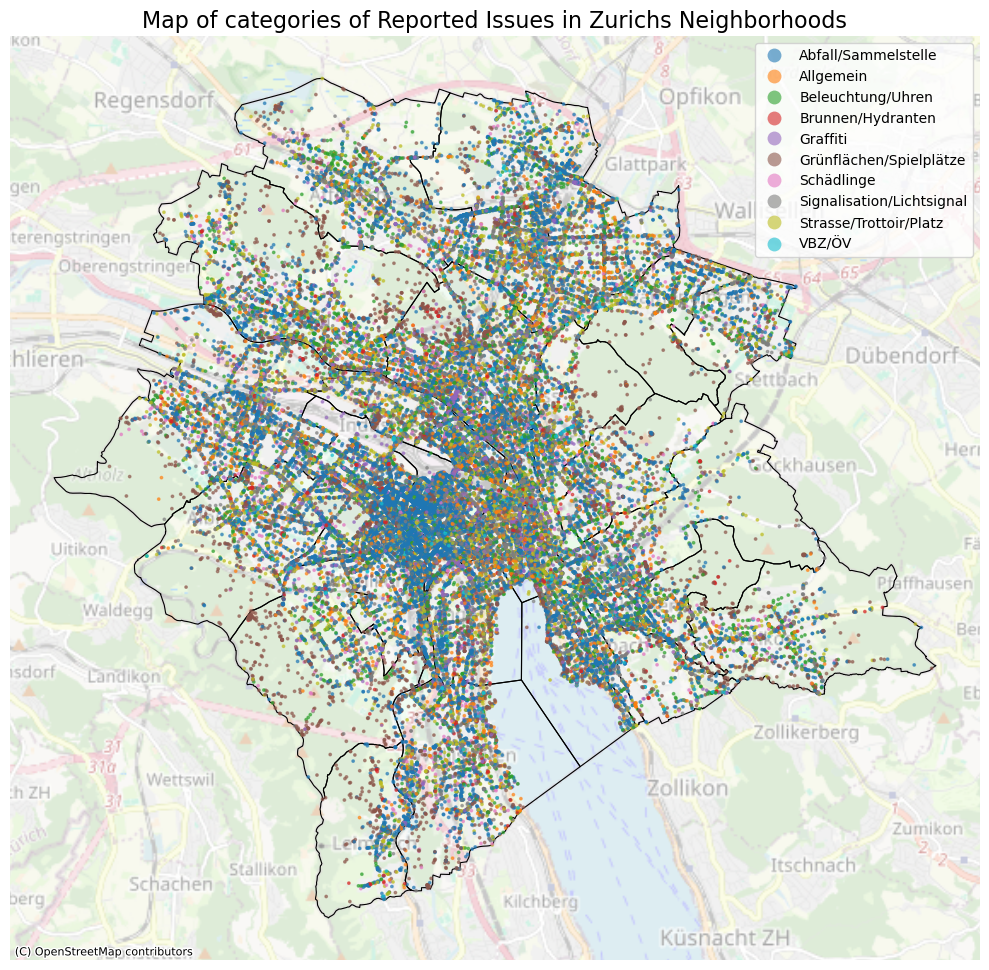

In [8]:
#reproject, because otherwise the backgroundmap is not on the right place
quartiere_3857 = zh_quartiere_clean.to_crs(epsg=3857)
reports_3857 = reports_with_quartiere.to_crs(epsg=3857)


fig, ax = plt.subplots(figsize=(10, 10))

quartiere_3857.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.8,
    zorder=2
)

reports_3857.plot(
    ax=ax,
    column="service_code",
    categorical=True,
    legend=True,
    markersize=3,
    alpha=0.6,
    zorder=3
)
#adding a basemap but make it transparent so the main focus is still on the spatial pattern
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=12,
    alpha=0.4
)

ax.set_title("Map of categories of Reported Issues in Zurichs Neighborhoods", fontsize=16)
ax.set_axis_off()

# setting this function, so the axes and titles are celan in the layout
plt.tight_layout()
#saving in output folder so i can later use it for my report
fig.savefig("../output/maps/OverviewMap_Categories_Neighborhood.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

It is apparent that more issues are reported in the central districts of Zurich, while fewer reports originate from the city’s outer borders. The natural areas, such as Lake Zurich and the surrounding hills (Uetliberg, Zürichberg, and partly the Waidberg), are also clearly visible in the spatial pattern, as almost no reports are submitted from these locations. This is likely due to the fact that fewer people live in these areas and that there is less infrastructure where issues could occur.

It is also visible, that ZueriwieNeu platform accepts reports on 10 different categories.

More detailed spatial and temporal patterns are analysed below.

---
**This analysis is guided by the follwoing research Questions:**
- *Which neighborood in Zurich receives the highest amount of reports?*
- *Which categories are the most common across the city of Zurich?*
- *How does the number of reports vary per month? vary per year?*
- *Are certain problem categories concentrated in specific neighbourhoods?*
- *Does processing time differ by different categories or neighborhoods?*
---

**Question 1:** Which neighorhoods in Zurich receives the highest amount of reports?

To analize this question, the reports per Quartiere (quartier_name) were counted and sorted, so the Quartier with most reports is on top. Afterwards the Information is visualized in a bar chart.  Also interested in how the pattern changes from analysing it in a larger scale,the same codes werde performed for the Kreise (kreis_name).

In [9]:
reports_per_quartier = (
    reports_with_quartiere
    .groupby("quartier_name")
    # the dataset was grouped by the quartiere, with the name it is more clear and more specified
    .size()
    #this functions counts how many times the quartiername is in the reports
    .sort_values(ascending=False)
    #this function sorts the values and with ascending = False, it sorts it from top to bottom
)

#saving the table as an output, because maybe it is needed in the report
reports_per_quartier.to_csv(
    "../output/tables/reports_per_quartier.csv",
    index=True
)

reports_per_quartier.head(25)

quartier_name
Langstrasse      6185
Sihlfeld         5233
Altstetten       4092
Unterstrass      3594
Wipkingen        3304
Höngg            3090
Oerlikon         2984
Hard             2854
Wollishofen      2834
Enge             2756
Seebach          2620
Alt-Wiedikon     2502
Affoltern        2419
Gewerbeschule    2230
Albisrieden      2047
Hottingen        1948
City             1740
Escher Wyss      1561
Werd             1529
Oberstrass       1516
Rathaus          1457
Hochschulen      1415
Friesenberg      1415
Hirslanden       1380
Seefeld          1280
dtype: int64

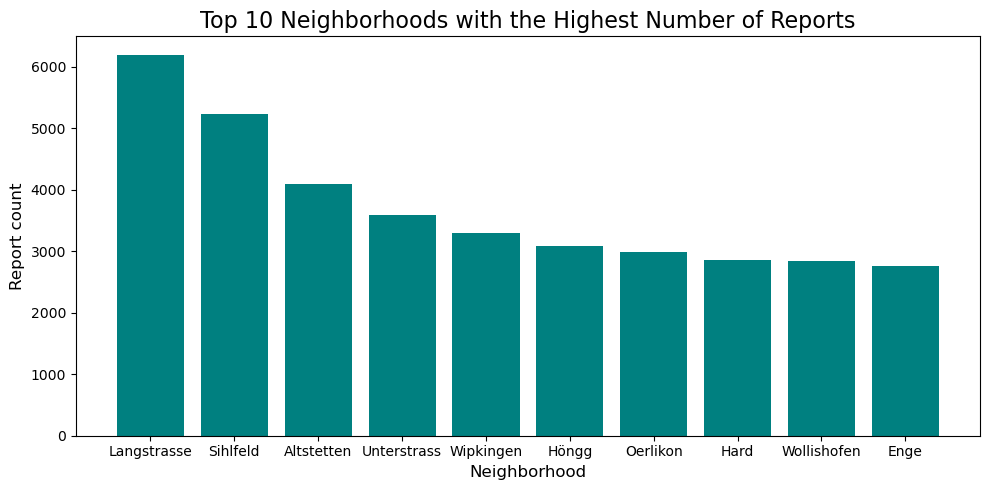

In [10]:
top_10_quartiere = reports_per_quartier.head(10)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    top_10_quartiere.index,
    top_10_quartiere.values,
    color="teal"
)

ax.set_title("Top 10 Neighborhoods with the Highest Number of Reports", fontsize=16)
ax.set_xlabel("Neighborhood", fontsize=12)
ax.set_ylabel("Report count", fontsize=12)

# setting this function, so the axes and titles are celan in the layout
plt.tight_layout()

fig.savefig("../output/maps/Top10_Neighborhoods_Mostreports.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [11]:
reports_per_kreise = (
    reports_with_quartiere
    # the dataset was grouped by the kreise, with the name it is more clear and more specified
    .groupby("kreis_name")
    #this functions counts how many times the kreis_name is in the reports
    .size()
     #this function sorts the values and with ascending = False, it sorts it from top to bottom
    .sort_values(ascending=False)
)

#saving the table as an output, because maybe it is needed in the report
reports_per_kreise.to_csv(
    "../output/tables/reports_per_district.csv",
    index=True
)

reports_per_kreise.head(5)
#only top 5, because there are just 12 kreise, so it doesnt have to be 10.

kreis_name
Kreis 4     10568
Kreis 3      9150
Kreis 11     8023
Kreis 10     6394
Kreis 2      6222
dtype: int64

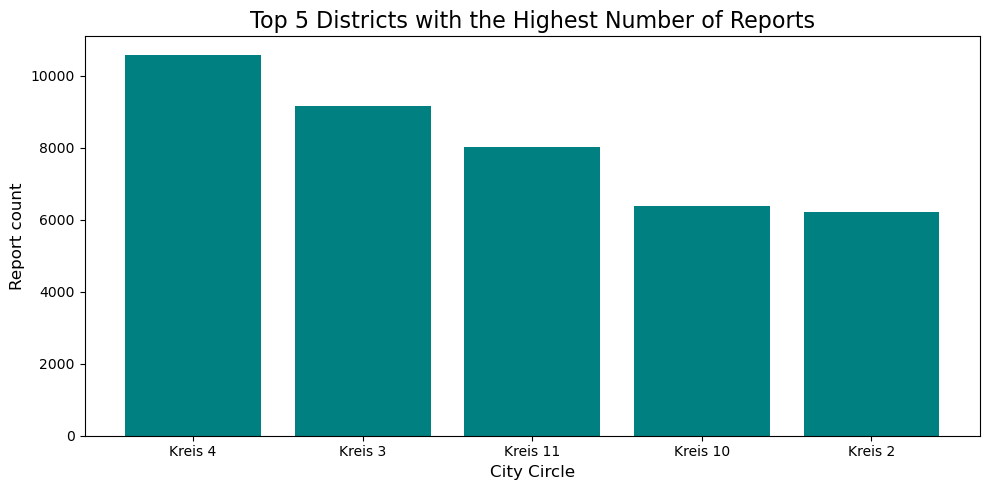

In [12]:
top_5_kreise = reports_per_kreise.head(5)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    top_5_kreise.index,
    top_5_kreise.values,
    color="teal"
)

ax.set_title("Top 5 Districts with the Highest Number of Reports", fontsize=16)
ax.set_xlabel("City Circle", fontsize=12)
ax.set_ylabel("Report count", fontsize=12)

# setting this function, so the axes and titles are celan in the layout
plt.tight_layout()

fig.savefig("../output/maps/Top5_district_Mostreports.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretation:**
We see that the Neighborhood Langstrasse has the most reports. Shilfeld and Altstetten are following up, but still 1000 reports less than the Langstrasse Neighborhood. Growing up in Zurich, this makes sense, because Langstrasse is famous for long nights of partying, alcohol,drugs and vandalism, which can maybye lead to more damages of public infrastructure. It also did not surprise me, that Neighborhoods in Kreis 7 and 8, the richer areas of Zruich have less damages to report than the top 10 ranked. An intereseting pattern on larger scale is also, that Kreis 9 is not in the top 5 Ranking of most Reports, eventhough the Quartier Altstetten (Kreis 9) is the third ranked Quartier counting Reports. That means that Albisrieden, the other Quartier in Kreis 9 doesn't have much reports. 

Whats important to note is that these counts are a absolut number. It is not relative, like the absolute reports devided by the the area or people living in that area. We can't calculate that, because we don't have this kind of data in the dataset.

---
**Question 2:** Which categories are the most common across the city of Zurich?

To answer this Question, the number of reports in each Categories (service_code) were counted. The Variable service_code was used, because it's the most simple categorization and not detailed, therefore a fixed category.They were counted, sorted and visualised in a bar chart.
The analysis uses absolute counts, which show the total number of reports per category. 
Additionally, the details on the first 20 reports of the dominat category were inspected to gain some insight.

In [13]:
category_counts = (
    reports_with_quartiere
    # the dataset was grouped by the service_codes so only the short cateogry is counted
    .groupby("service_code")
    #this functions counts how many times the service_codes is in the reports
    .size()
     #this function sorts the values and with ascending = False, it sorts it from top to bottom
    .sort_values(ascending=False)
)

#saving the table as an output, because maybe it is needed in the report
category_counts.to_csv(
    "../output/tables/category_counts.csv",
    index=True
)

category_counts

service_code
Abfall/Sammelstelle          27339
Signalisation/Lichtsignal    10972
Strasse/Trottoir/Platz        9868
Grünflächen/Spielplätze       7234
Beleuchtung/Uhren             5407
Allgemein                     3964
Graffiti                      3759
VBZ/ÖV                        1881
Brunnen/Hydranten             1287
Schädlinge                     895
dtype: int64

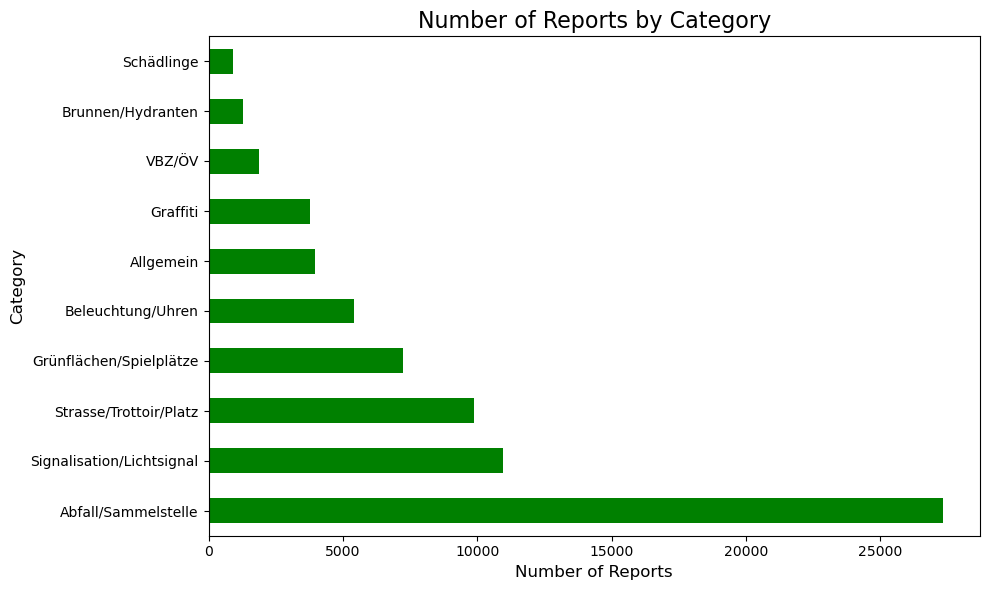

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

category_counts.plot(
   #horizontal bar chart so it is visible at first sight and its an ordered list
    kind="barh",
    ax=ax,
    color="green"
)

ax.set_title("Number of Reports by Category", fontsize=16)
ax.set_xlabel("Number of Reports", fontsize=12)
ax.set_ylabel("Category", fontsize=12)
# setting this function, so the axes and titles are celan in the layout
plt.tight_layout()

fig.savefig(
    "../output/maps/reports_per_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
#filtered for the column service code, where it is the most reported one for details, to get some insight on what this category could mean
details_abfall = reports_with_quartiere.loc[
    reports_with_quartiere["service_code"] == "Abfall/Sammelstelle",
    ["detail"]
]

#saving the table as an output, because maybe it is needed in the report
details_abfall.to_csv(
    "../output/tables/details_abfall.csv",
    index=True
)

details_abfall.head(20)

,detail
4,Arbeitskiste ist rund herum verschmiert
32,Schmierereien und Graffiti an der Wand und am Brückenwid...
43,Dieses defekte Velo versperrt seit Monaten den Platz für...
56,Defektes Velo seit Monaten dort.
68,Bitte Abfallsäcke aufräumen. Die Bewohner konnten über d...
70,Ilegalle deponie Überlandstrasse 215 beim Brunnen
71,Illegale Entsorgung
109,Grill am Straßenrand entsorgt.
111,"Graffiti bei Treppe zum Grossmünster, neben Haus zum Loch."
126,Die Unterführung Bucheggstrasse ist schmutzig und wurde ...


**Interpretation:** The Category Abfall/sammelstelle is almost three times more reported than the second most reported Category. But
looking at the details about the 20 first Cateogry Abfall/Sammelstelle, it is alsovisible how it sometimes corrleates with dirty streets or walls.
Some of these reports are maybye missleading in the Category Abfall/Sammelstelle. The same could be with the other categories. But still
with this many reports, it's maybye the most important category.

---
**Question 3:** How does the number of reports vary per month? vary per year?

This question examines temporal patterns in the ZüriWieNeu reports. The goal is to understand wether the number of reports changes over time and whether there are seasonal patterns. For this purpose, the reports are grouped by year and by month. Analysing reports by year shows long-term changes in reporting activity. Analysing reports by month helps identify possible seasonal patterns. 

Both were directly visualised to see the macro level pattern and not look at numbers, because especially in months with visualization the effect is better visible.

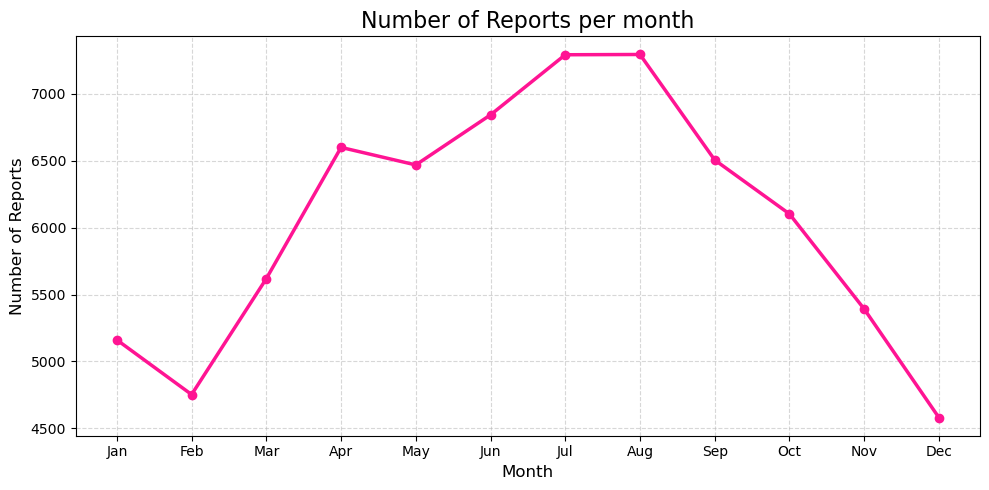

In [16]:
#for a better visualisation, i deinfe the months in a list as shortcuts
#because there are not in the dataset
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

reports_per_month = (
    reports_with_quartiere 
    .groupby("month_requested")
    .size()
)

fig, ax = plt.subplots(figsize=(10, 5))

reports_per_month.plot(
    kind="line",
    ax=ax,
    color="deeppink",
    linewidth=2.5,
    marker="o",
    markersize=6,
    legend=False
)

ax.set_title("Number of Reports per month", fontsize=16)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Number of Reports", fontsize=12)

ax.set_xticks(reports_per_month.index)
ax.set_xticklabels(month_names)

ax.grid(axis="both", linestyle="--", alpha=0.5)

# setting this function, so the axes and titles are celan in the layout
plt.tight_layout()

fig.savefig("../output/maps/number_reports_month.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

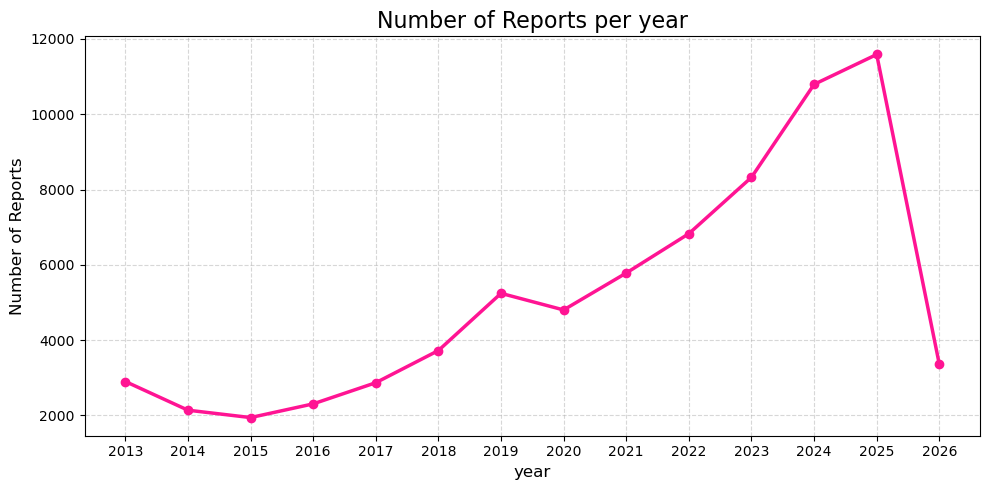

In [17]:
reports_per_year = (
    reports_with_quartiere
    # the dataset was grouped by the month_requested 
    .groupby("year_requested")
    #this functions counts how many times the month_requested is in the reports
    .size()
)

fig, ax = plt.subplots(figsize=(10, 5))

reports_per_year.plot(
    kind="line",
    ax=ax,
    color="deeppink",
    linewidth=2.5,
    marker="o",
    markersize=6,
    legend=False
)
ax.set_title("Number of Reports per year", fontsize=16)
ax.set_xlabel("year", fontsize=12)
ax.set_ylabel("Number of Reports", fontsize=12)

ax.set_xticks(reports_per_year.index)
ax.set_xticklabels(reports_per_year.index)

ax.grid(axis="both", linestyle="--", alpha=0.5)
# setting this function, so the axes and titles are celan in the layout
plt.tight_layout()

fig.savefig("../output/maps/number_reports_year.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Interpretation:**
Looking at the number of reports per month, there can be a little peak identified in the summer months . Then the number of reports is declining again. Also Apirl has a high amount of reports. My interpretation of this pattern is, that people are more outside in the summer months than in the winter. This leads to more complicatiosn at "Abfall" or also "Graffiti" or " maybe Grünflächen und Spielplätze", but also to more reports, because people who report stuff like this are more outside aswell.

Looking at the number of reports per year, it is a clear trend to more reports with more years. Except the 2026, but this can be ignored, because whiloe downloading the reports dataset, it was only april, so only 4 months of 12. Otherwise there is a little less reports during 2020, which could be because of the corona Pandemic. The rising sum of reports over the year could be a sign of more people in Zurich reporting these things or also due to techonoloogical progress, so that people report more issues on the phone directly.

---
**Question 4:** Are certain problem categories concentrated in specific neighbourhoods?

This question investigates whether specific types of reports occur more frequently in some neighbourhoods than in others. To answer this, the number of reports is counted for each combination of neighbourhood and report category. The frequency table was made for the neighborhoods of zurich using the absolute count.

In [18]:
category_by_quartier = pd.crosstab(
    reports_with_quartiere["quartier_name"],
    reports_with_quartiere["service_code"]
)

#saving the table as an output, because maybe it is needed in the report
category_by_quartier.to_csv(
    "../output/tables/category_by_quartier.csv",
    index=True
)

category_by_quartier.head()

service_code,Abfall/Sammelstelle,Allgemein,Beleuchtung/Uhren,...,Signalisation/Lichtsignal,Strasse/Trottoir/Platz,VBZ/ÖV
quartier_name,,,,,,,
Affoltern,779,109,246,...,374,327,73
Albisrieden,644,107,137,...,346,336,48
Alt-Wiedikon,1278,148,168,...,331,295,46
Altstetten,1400,254,242,...,776,592,110
City,437,139,109,...,374,381,74


With 10 categories and 36 neighborhoods , it is difficult to detect a pattern in these mixed numbers. However it is visible that Abfall/Sammelstelle is these head() Neighborhoods the most reported issue, while Schädlinge is mostly the least often reported issue. 

Therefore it would be interessting, to look at a map, which shows the second most dominant category for each Neighborhood without beeing influenced by the category Abfall/Samnmelstelle.

In [19]:
# new variable without Abfall/Sammelstelle,so other dominant category per neighborhood are visible 
category_no_abfall = category_by_quartier.drop(columns=["Abfall/Sammelstelle"])

# the most dominant category (most count of category) besides Abfall/Sammelstelle in every row (neighborhood) and a new datacolumn name
dominant_category = category_no_abfall.idxmax(axis=1)
dominant_category.name = "dominant_category_without_abfall"
#merge the data set dominant_category with the zh_quartiere_clean dataset with the variable quartier_name which is in both dataframes, so that it easier to visualize in a map
zh_quartiere_clean = zh_quartiere_clean.merge(
    dominant_category,
    left_on="quartier_name",
    right_index=True,
    how="left"
)

zh_quartiere_clean.head(2)

,quartier_name,quartier_number,kreis_name,kreis_number,geometry,dominant_category_without_abfall
0,Alt-Wiedikon,31,Kreis 3,3,"POLYGON ((2680606.662 1247034.584, 2680626.356 1247041.6...",Signalisation/Lichtsignal
1,Witikon,74,Kreis 7,7,"POLYGON ((2685858.632 1246502.629, 2685860.738 1246508.5...",Grünflächen/Spielplätze


Now the GeoDataFrame zh_quartiere_clean also contains a column with the dominant category, without abfall. The next step is to viusalize this connection in a categorcial Map.

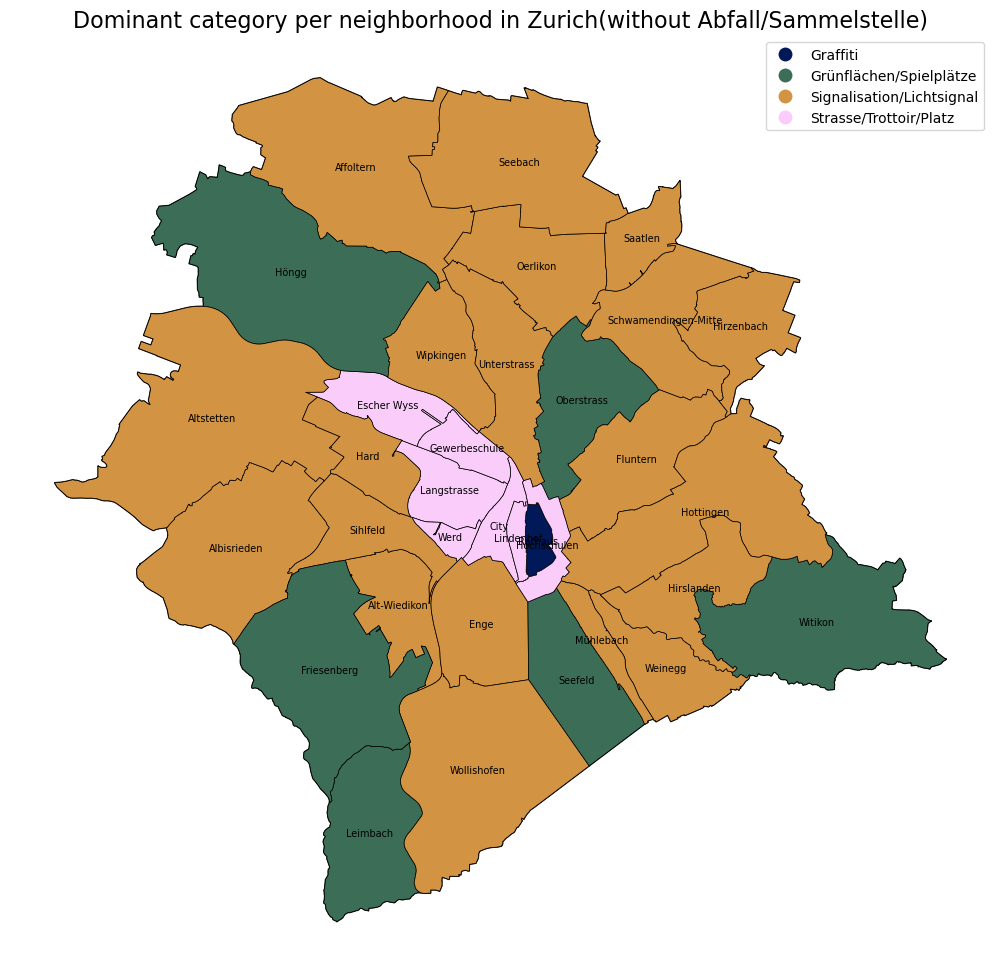

In [20]:
fig, ax = plt.subplots(figsize=(14, 10))

zh_quartiere_clean.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1,
    zorder=1
)
zh_quartiere_clean.plot(
    ax=ax,
    column="dominant_category_without_abfall",
    cmap=cmc.batlow,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    zorder=2
)

for idx, row in zh_quartiere_clean.iterrows():
    centroid = row.geometry.centroid
    
    ax.text(
        centroid.x,
        centroid.y,
        row["quartier_name"], 
        fontsize=7,
        ha="center",
        va="center",
        zorder=3
    )

ax.set_title(
    "Dominant category per neighborhood in Zurich(without Abfall/Sammelstelle)",
    fontsize=16
)
ax.axis("off")
# setting this function, so the axes and titles are celan in the layout
plt.tight_layout()

fig.savefig("../output/maps/dominant_category_neighborhood_without_Abfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretation:** After removing the Category Abfall/Sammelstelle, the Map got much more interesting. We can see that Signalisation/Lichtsignale is also a issue often reported. 6 neighborhoods also reported often issues about Grünflächen und Spielplätze.Interestingly is also the clustering of issues about Strasse/Troitoir/Platz in the center of Zurich. These 3 categories are also the most frequent ones besides Abfall/Sammelstelle. However the Rathaus Neighborhood has most isssues with Graffiti. Thats interesting, because Graffiti is the 7th most reported issue of all categories. Looks like it is a hotspot for Graffitis and Reporting of illegal Graffitis.

---
**Question 5:** Does processing time differ by different categories or neighborhoods?

This question examines whether the time between a report being submitted and updated differs by report category or neighborhood. The analysis uses the "processing_time_days" column, which was calculated during the data cleaning step.

Because processing times can contain strong outliers, the median processing time is used as the main comparison measure. The mean and maximum values are also calculated, but they are interpreted more carefully because they can be strongly influenced by very long individual cases.

However, it is important to note that the processing time is calculated using the request_datetime and the updated_datetime. The updated_datetime does not always represent the moment when an issue was actually resolved; it only reflects the resolution date if the report status was explicitly changed to fixed. This means that the calculated processing times are an approximation.
Nevertheless, the data inspection in the reports_cleaning notebook showed that the vast majority of reports are indeed marked as fixed, which makes this approximation acceptable for the purposes of this analysis.

In [21]:
processing_by_category = (
    reports_with_quartiere
    .groupby("service_code")["processing_time_days"]
    .agg(["mean", "median", "max"])
    .sort_values("median", ascending=False)
)

#saving the table as an output, because maybe it is needed in the report
processing_by_category.to_csv(
    "../output/tables/processing_by_category.csv",
    index=True
)

processing_by_category

,mean,median,max
service_code,,,
Grünflächen/Spielplätze,4.758113,2.595781,802.120880
Graffiti,11.350376,1.937049,300.900000
Strasse/Trottoir/Platz,3.042766,1.512529,1726.850394
VBZ/ÖV,3.307727,1.246597,106.114421
Brunnen/Hydranten,3.742011,1.074190,180.718935
Beleuchtung/Uhren,2.622426,1.030822,1293.738623
Allgemein,1.662802,0.777720,177.788148
Signalisation/Lichtsignal,4.716689,0.773223,789.180926
Schädlinge,1.075757,0.639954,17.089306


It is visible, that there are some very strong outliers ind every category. While the mean and median are mostly below 10 day, all the max prcessing days are all over 10  most of them in the range of hundert. Therefore is it important to use the median as a comparison variable.

To display this information, the median are plotted in a horizontal bar chart. Addditionally the median proccessing time is sorted from shortest processing time to longest, so that it is imidiately clear, which category takes the longest usually to proceess. 

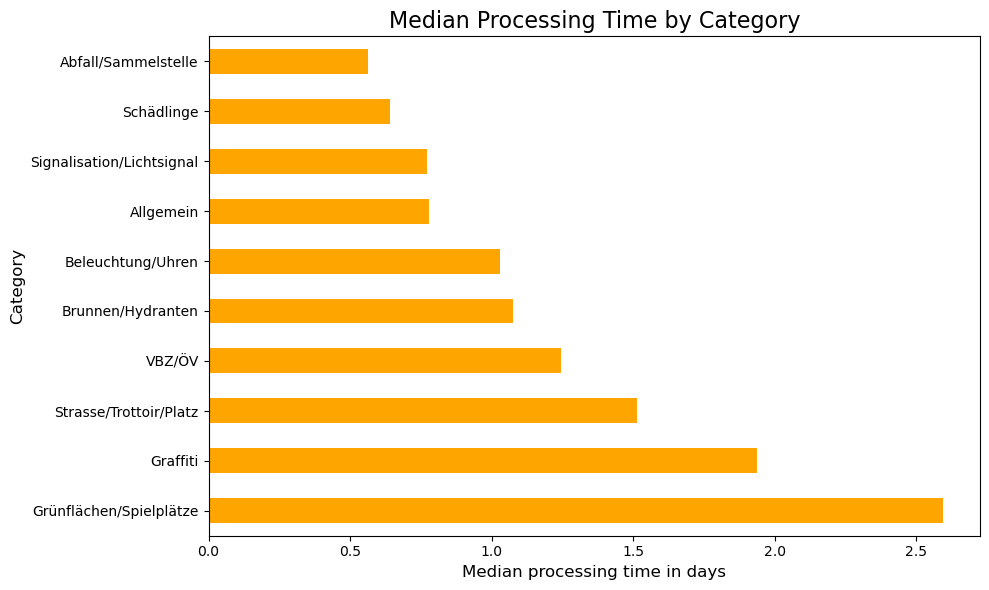

In [22]:
processing_by_category_sorted = processing_by_category.sort_values(
    "median",
    ascending=False
)

fig, ax = plt.subplots(figsize=(10, 6))

processing_by_category_sorted["median"].plot(
    kind="barh",
    ax=ax,
    color="orange"
)

ax.set_title("Median Processing Time by Category", fontsize=16)
ax.set_xlabel("Median processing time in days", fontsize=12)
ax.set_ylabel("Category", fontsize=12)
# setting this function, so the axes and titles are celan in the layout
plt.tight_layout()

fig.savefig("../output/maps/median_processingtime_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretation:** The category Grünfläche/Spielplätze shows the longest average processing time, taking almost twice as long as Abfall/Sammelstelle, which is the most frequently reported issue (as shown in the tables in Question 2). The underlying reason for this difference is not entirely clear. One possible explanation is that issues related to green spaces and playgrounds may require more complex coordination or specialised work, whereas problems involving Strasse/Trottoir/Platz might be prioritised more highly due to their potential to pose immediate risks to traffic participants. At the same time, unresolved playground issues could also pose safety risks, particularly for children, so the prioritisation logic is not straightforward.

Overall, the data indicates that most issues regardless of category are resolved very quickly, typically within two and a half days, with only a few outliers. This suggests that the city processes and resolves reported issues efficiently and with a high level of responsiveness.

---
Now for the neighborhood:

In [23]:
processing_by_neighborhood = (
    reports_with_quartiere
    .groupby("quartier_name")["processing_time_days"]
    .agg(["mean", "median", "max"])
    .sort_values("median", ascending=False)
)

#saving the table as an output, because maybe it is needed in the report
processing_by_neighborhood.to_csv(
    "../output/tables/processing_by_neighborhood.csv",
    index=True
)

processing_by_neighborhood. head()

,mean,median,max
quartier_name,,,
Friesenberg,3.679411,1.242836,272.719016
Witikon,3.685206,1.159850,276.845694
Hochschulen,4.509261,1.130509,274.328461
Oberstrass,3.992908,1.000029,300.020359
Wipkingen,3.473224,0.979641,387.683924


It is visible, that there are some very strong outliers ind every neighborhood. While the mean and median are mostly below 5 day, all the max prcessing days are all in the range of hundert. Therefore is it important to use the median as a comparison variable.

To display this information, the median are plotted in a horizontal bar chart. Addditionally the median proccessing time is sorted from shortest processing time to longest, so that it is imidiately clear, which neighborhood takes the longest usually to proceess. 

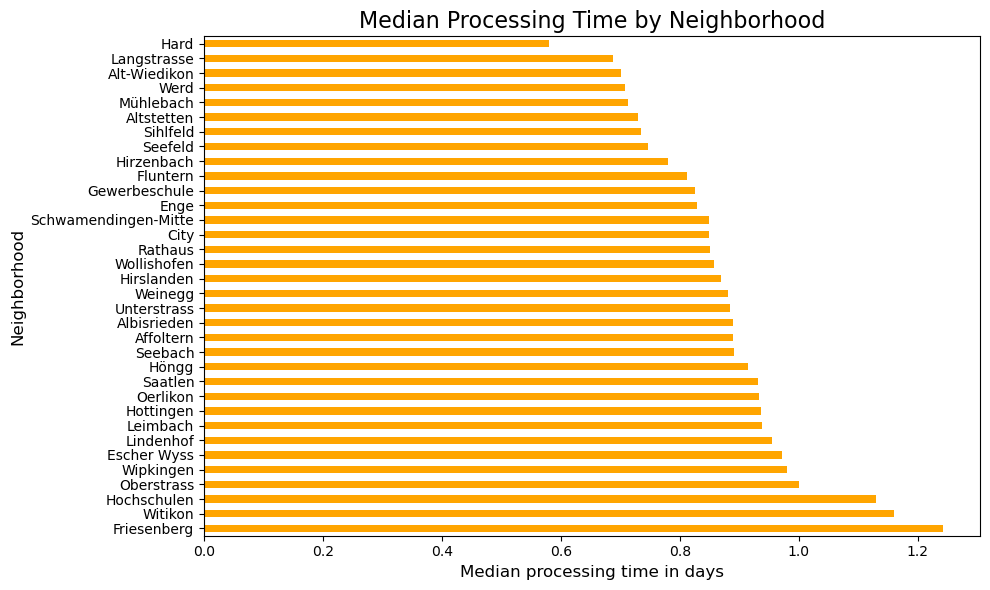

In [24]:
processing_by_neighborhood_sorted = processing_by_neighborhood.sort_values(
    "median",
    ascending=False
)

fig, ax = plt.subplots(figsize=(10, 6))

processing_by_neighborhood_sorted["median"].plot(
    kind="barh",
    ax=ax,
    color="orange"
)

ax.set_title("Median Processing Time by Neighborhood", fontsize=16)
ax.set_xlabel("Median processing time in days",fontsize=12)
ax.set_ylabel("Neighborhood", fontsize=12)
# setting this function, so the axes and titles are celan in the layout
plt.tight_layout()

fig.savefig("../output/maps/median_processingtime_neighborhood.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Interpretation:** The neighborhood Friesenberg takes almost twice as long as the Hard neighborhood. Hard Neighborhood is part of the top 10 neighborhoods with the most reports. That means, that eventhough there are many reports, they get resolved quickly. Hard neighborhood is also part of the inner city circle so it's important that problems get resolved quickly. For the neighborhoods Friesenberg, Witikon and Hochschulen the proccesing days are similar high.

Overall, the data indicates that most issues regardless of the neighborhood are resolved very quickly, typically within 1 day. This suggests that the city processes and resolves reported issues efficiently and with a high level of responsiveness.

However with both visualizations, category and neighborhoods, it's important to remember, that there are some extreme outliers where the processing time is almost a year. So it could depend on the exact detail of the issue and how easily it is sorted out.